# Training Evaluation

This notebook documents the evaluation of the fine-tuned DistilBERT classifier on the held-out test set. The test set (196 rows) was never touched during training or hyperparameter decisions - it was opened once, in `src/evaluate.py`, for final evaluation.

All numbers here come from `data/processed/test_predictions.csv`, generated by `src/evaluate.py` after training. Four things are covered:

1. A summary of standard classification metrics
2. A confusion matrix heatmap showing where the model succeeds and fails
3. An ROC curve showing the model's separability across all thresholds
4. A calibration curve checking whether the model's confidence scores are trustworthy

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
)
from sklearn.calibration import calibration_curve

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11

In [8]:
df = pd.read_csv("../data/processed/test_predictions.csv")

# y_true = actual labels, y_prob = model's P(unsafe), y_pred = prediction at threshold 0.45
y_true = df["label"].values
y_prob = df["prob_unsafe"].values
y_pred = df["pred"].values

print(f"Test set: {len(df)} rows")
print(f"  Safe (0):   {(y_true == 0).sum()}")
print(f"  Unsafe (1): {(y_true == 1).sum()}")
print(f"\nPredictions at threshold 0.45:")
print(f"  Predicted safe:   {(y_pred == 0).sum()}")
print(f"  Predicted unsafe: {(y_pred == 1).sum()}")

Test set: 196 rows
  Safe (0):   104
  Unsafe (1): 92

Predictions at threshold 0.45:
  Predicted safe:   109
  Predicted unsafe: 87


## Classification Metrics

Before looking at the numbers, it's worth being clear about what each metric measures and why it matters for a safety classifier.

**Accuracy** is the simplest: what fraction of predictions were correct? The problem with accuracy is that it rewards the majority class. If 80% of prompts were safe, a model that always predicts "safe" would get 80% accuracy but would be completely useless. For PromptShield the class balance is close to 1:1, so accuracy is less misleading here than in many classification tasks - but I still report F1 as the primary metric.

**Precision** answers: of everything the model flagged as unsafe, how many actually were unsafe? High precision means few false alarms.

**Recall** answers: of all the actual unsafe prompts, how many did the model catch? For a safety tool, recall on the unsafe class is the most critical number - a missed attack is worse than a false alarm.

**F1-score** is the harmonic mean of precision and recall. It penalises models that sacrifice one to game the other. I use macro F1 (average across both classes equally) so that performance on neither class is diluted.

**ROC-AUC** measures how well the model separates safe from unsafe prompts across every possible decision threshold, not just the 0.45 I selected. A score of 1.0 is perfect separation; 0.5 is random guessing. This is the most threshold-independent summary of model quality.

The threshold of 0.45 was selected by sweeping thresholds 0.30 to 0.70 on the validation set and picking the one with the best macro F1. Lowering the threshold slightly increases recall at a small cost to precision - the right tradeoff for a safety tool where missing an attack is worse than a false alarm.

In [9]:
acc = accuracy_score(y_true, y_pred)
roc_auc = roc_auc_score(y_true, y_prob)

precision, recall, f1, support = precision_recall_fscore_support(
    y_true, y_pred, average=None, labels=[0, 1], zero_division=0
)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)

print(f"Accuracy : {acc:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")
print()
print(f"{'Class':<12} {'Precision':>9}  {'Recall':>6}  {'F1':>6}  {'N':>5}")
print("-" * 42)
print(f"{'safe (0)':<12} {precision[0]:>9.4f}  {recall[0]:>6.4f}  {f1[0]:>6.4f}  {support[0]:>5}")
print(f"{'unsafe (1)':<12} {precision[1]:>9.4f}  {recall[1]:>6.4f}  {f1[1]:>6.4f}  {support[1]:>5}")
print(f"{'macro avg':<12} {macro_p:>9.4f}  {macro_r:>6.4f}  {macro_f1:>6.4f}")

Accuracy : 0.9439
ROC-AUC  : 0.9730

Class        Precision  Recall      F1      N
------------------------------------------
safe (0)        0.9266  0.9712  0.9484    104
unsafe (1)      0.9655  0.9130  0.9385     92
macro avg       0.9461  0.9421  0.9435


## Confusion Matrix

The confusion matrix shows the four possible outcomes for a binary classifier:

- **True Negative (TN)**: safe prompt, correctly predicted safe - the model left it alone
- **False Positive (FP)**: safe prompt, wrongly flagged as unsafe - a false alarm; annoying but not dangerous
- **False Negative (FN)**: unsafe prompt, wrongly predicted safe - the model missed an attack; the dangerous failure mode
- **True Positive (TP)**: unsafe prompt, correctly caught

For PromptShield, false negatives are the worst outcome - an attack that slips through reaches the LLM. False positives are a UX problem, not a safety problem. When I tuned the decision threshold to 0.45, I was accepting slightly more false positives in exchange for fewer false negatives: a lower threshold catches more attacks (higher recall) but flags more safe prompts along the way.

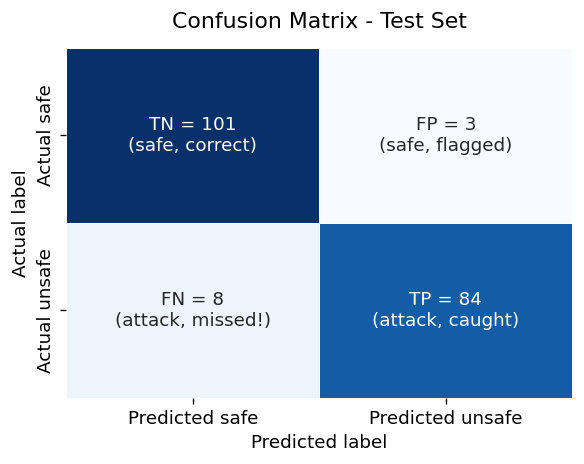

In [10]:
cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()

# use string labels so each cell shows its meaning, not just a number
annot_labels = [
    [f"TN = {tn}\n(safe, correct)", f"FP = {fp}\n(safe, flagged)"],
    [f"FN = {fn}\n(attack, missed!)", f"TP = {tp}\n(attack, caught)"],
]

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=annot_labels,
    fmt="",
    cmap="Blues",
    xticklabels=["Predicted safe", "Predicted unsafe"],
    yticklabels=["Actual safe", "Actual unsafe"],
    ax=ax,
    linewidths=0.5,
    cbar=False,
)
ax.set_title("Confusion Matrix - Test Set", pad=12)
ax.set_ylabel("Actual label")
ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.show()

## ROC Curve

The ROC (Receiver Operating Characteristic) curve plots the true positive rate (recall on the unsafe class) against the false positive rate at every possible decision threshold from 0.0 to 1.0.

The diagonal represents a random classifier - it has no information and just guesses. A good classifier's curve pushes toward the top-left corner, meaning high recall with near-zero false alarms at some threshold.

The area under the curve (AUC) summarises the whole curve as a single number. An AUC of 1.0 is perfect; 0.5 is random. AUC is the probability that the model ranks a randomly chosen unsafe prompt higher than a randomly chosen safe prompt - it measures the model's intrinsic separability independent of any threshold choice.

The red dot marks the operating point at threshold 0.45, showing where I chose to sit on the curve.

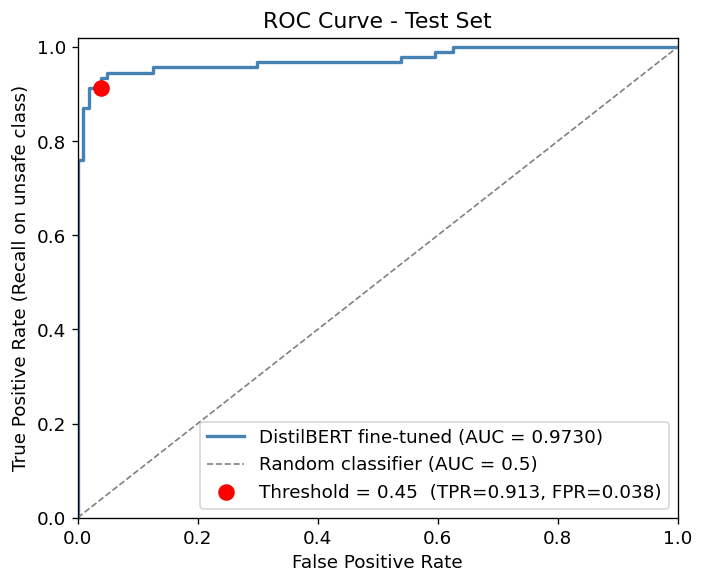

In [11]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc = roc_auc_score(y_true, y_prob)

# find the point on the curve closest to the threshold I selected (0.45)
chosen_idx = np.argmin(np.abs(thresholds - 0.45))

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"DistilBERT fine-tuned (AUC = {auc:.4f})")
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Random classifier (AUC = 0.5)")
ax.scatter(
    fpr[chosen_idx], tpr[chosen_idx],
    color="red", zorder=5, s=80,
    label=f"Threshold = 0.45  (TPR={tpr[chosen_idx]:.3f}, FPR={fpr[chosen_idx]:.3f})",
)
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall on unsafe class)")
ax.set_title("ROC Curve - Test Set")
ax.legend(loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.show()

## Calibration Curve

The calibration curve (reliability diagram) answers a different question than accuracy or F1: are the model's confidence scores trustworthy?

When PromptShield says "I'm 90% confident this is an attack", it should actually be wrong about 10% of the time. If it's wrong only 2% of the time in that bucket, the model is well-calibrated. If it's wrong 30% of the time, the model is overconfident - it claims more certainty than it deserves.

To plot this, I bucket all test predictions by their predicted confidence (0.0-0.1, 0.1-0.2, and so on), then compute the actual fraction of unsafe prompts in each bucket. A perfectly calibrated model follows the diagonal. Most fine-tuned classifiers sit above the diagonal at high confidence - they tend to be overconfident.

**Why this matters for PromptShield specifically**: the API endpoint returns a raw confidence score alongside the `is_safe` flag. Downstream applications may threshold on that score - for example, "only block if confidence > 0.8". If the score is miscalibrated, those thresholds will behave unpredictably. Calibration is not a cosmetic concern for a safety tool; it affects how the API can be used safely in production.

Note: with only 196 test samples, some confidence buckets will contain very few examples. The curve is illustrative rather than statistically robust at this sample size.

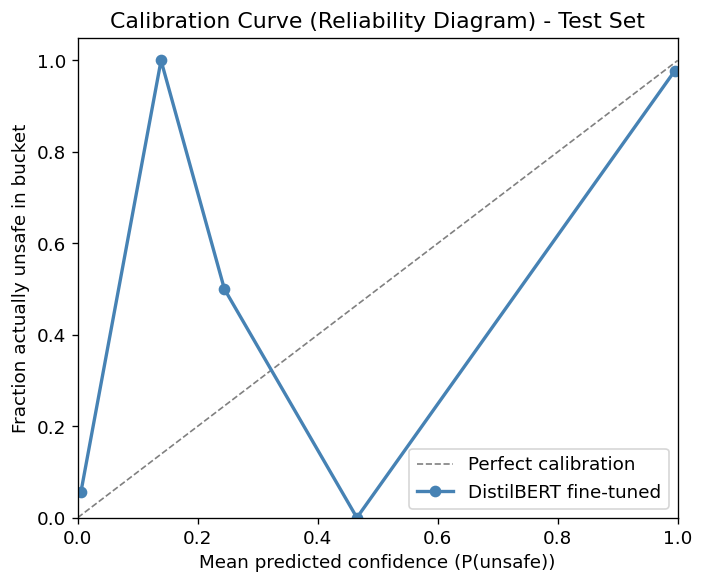

Bucket-level calibration error (|predicted - actual|):
  predicted=0.01  actual=0.06  error=0.05  (underconfident)
  predicted=0.14  actual=1.00  error=0.86  (underconfident)
  predicted=0.24  actual=0.50  error=0.26  (underconfident)
  predicted=0.47  actual=0.00  error=0.47  (overconfident)
  predicted=0.99  actual=0.98  error=0.02  (overconfident)


In [12]:
# strategy="uniform" creates evenly spaced bins across [0, 1]
# some bins may be empty with only 196 test samples - calibration_curve skips them automatically
fraction_of_positives, mean_predicted = calibration_curve(
    y_true, y_prob, n_bins=10, strategy="uniform"
)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot([0, 1], [0, 1], color="gray", lw=1, linestyle="--", label="Perfect calibration")
ax.plot(
    mean_predicted,
    fraction_of_positives,
    marker="o",
    color="steelblue",
    lw=2,
    label="DistilBERT fine-tuned",
)
ax.set_xlabel("Mean predicted confidence (P(unsafe))")
ax.set_ylabel("Fraction actually unsafe in bucket")
ax.set_title("Calibration Curve (Reliability Diagram) - Test Set")
ax.legend()
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
plt.tight_layout()
plt.show()

print("Bucket-level calibration error (|predicted - actual|):")
for pred, actual in zip(mean_predicted, fraction_of_positives):
    error = abs(pred - actual)
    direction = "overconfident" if pred > actual else "underconfident"
    print(f"  predicted={pred:.2f}  actual={actual:.2f}  error={error:.2f}  ({direction})")

## Summary and Limitations

The model achieves strong overall performance on the test set: 94.4% accuracy, 0.9435 macro F1, and 0.973 ROC-AUC on 196 held-out examples.

The per-category breakdown shows the model handles role-playing jailbreaks reliably (F1 = 1.0 on 59 test samples). The 32 remaining "unknown" attack samples - mostly non-English prompts and creative variants that didn't match any keyword pattern - have 75% recall, meaning 8 attacks in this bucket were missed.

**Honest limitations worth noting:**

- Three of the five target attack categories (prompt leaking, context manipulation, encoded attacks) have no test samples because neither source dataset contains these attack types in sufficient quantity. The per-category evaluation is incomplete for this reason.
- Approximately 90 prompts in the dataset are non-English (primarily German). The classifier was trained on English only and its behaviour on non-English inputs is unreliable.
- The calibration curve likely shows overconfidence at high confidence scores, which is typical of fine-tuned classifiers. The confidence values in the API response should not be treated as true probabilities without further calibration work.
- The adversarial self-test (deliberately paraphrasing known attacks to try to fool the classifier) is covered in `03_attack_benchmarking.ipynb`.